# M11.1 — Physical GW support in the processing context

## Objective

This notebook studies one specific mismatch identified between the M10 synthetic pipeline and the real-data inference pipeline.

In M10, the detector-projected waveform is restricted to a physical window of at most 4 s before being embedded into the longer processing context. The context therefore protects whitening/filtering against boundary effects, but it does **not** contain physical GW signal outside the final 4 s window.

For continuous real strain, by contrast, the processing context can contain physical signal immediately before the final 4 s crop.

The purpose of M11.1 is to isolate and quantify the effect of this difference before introducing any other change to the simulation pipeline.


## 1. Hypothesis and experimental design

Because whitening is a finite-support linear operation, removing physical signal immediately before the final output window can modify the processed samples near the beginning of the 4 s CNN input.

We compare two otherwise identical constructions:

- **A1 — M10-compatible:** inject only the projected signal selected by the M10 physical window (`m10_windowed`).
- **A2 — Full physical context:** inject the full detector projection and let the processing-context segment select the physically overlapping part (`full_projection`).

For the first diagnostic we use `strain_mode="gw_only"`, i.e. zero noise, so that any difference between A1 and A2 is caused exclusively by the signal support in the processing context.

Controlled quantities:
- physical BBH parameters;
- geocentric coalescence time;
- detector projection and time delays;
- final 4 s placement;
- PSD and processing;
- random seed.

The only intended experimental variable is `signal_context_mode`.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()

# Ajusta según dónde ejecutes el notebook
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SimulationConfig
from src.dataset import DatasetBuilder
from src.parameters import CBCParameters

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

## 2. Numerical configuration

For this first signal-only diagnostic, SNR rescaling is disabled. The goal is not yet to reproduce the full M10 training distribution, but to isolate the mathematical effect of signal support through the same whitening/cropping machinery.

The processing context is 1664 samples on each side, corresponding to 0.40625 s at 4096 Hz.


In [2]:
SEED = 123
T_GEO = 1126259462.0

config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    # Para esta primera prueba prefiero NO reescalar distancia
    target_network_snr_range=None,

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

## 3. Controlled BBH systems

The comparison is only informative when the physical waveform extends beyond the 4 s output window.

The initially considered 20+20, 40+40 and 80+80 \(M_\odot\) systems produce waveforms shorter than 4 s from 30 Hz with the current approximant/configuration, so A1 and A2 are expected to be identical for them.

A 5+5 \(M_\odot\) system is therefore included as the main diagnostic case. It produces a waveform longer than 4 s and allows the pre-output physical signal to populate the processing context.

The higher-mass systems are retained as useful **null controls**: if the implementation is correct, they should show no A1/A2 difference.


In [3]:
COMMON = dict(
    distance=500.0,
    inclination=1.0,
    ra=1.0,
    dec=0.3,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.5,
)

cases = {
    "05_05": CBCParameters(
        mass_1=5.0,
        mass_2=5.0,
        **COMMON,
    ),
    "20_20": CBCParameters(
        mass_1=20.0,
        mass_2=20.0,
        **COMMON,
    ),
    "40_40": CBCParameters(
        mass_1=40.0,
        mass_2=40.0,
        **COMMON,
    ),
    "80_80": CBCParameters(
        mass_1=80.0,
        mass_2=80.0,
        **COMMON,
    ),
}

## 4. Paired builders

A fresh `DatasetBuilder` is constructed for each branch of the comparison using the same seed. This prevents sequential calls from advancing shared RNG state and ensures that placement and all stochastic choices preceding the context-mode branch remain paired.


In [4]:
def make_builder(seed):
    return DatasetBuilder.from_config(
        config=config,
        detector_names=["H1", "L1", "V1"],
        signal_processor_kwargs={
            "whitening_method": "psd",
            "apply_highpass": False,
            "apply_lowpass": False,
            "apply_standardization": False,
            "output_mode": "crop_to_config",
        },
        rng=np.random.default_rng(seed),
    )

## 5. Generate A1 and A2

For each controlled BBH system, two samples are generated with identical parameters and seed. The only changed argument is the signal-context policy.


In [5]:
results = {}

for case_name, params in cases.items():

    builder_a = make_builder(SEED)
    builder_b = make_builder(SEED)

    a1 = builder_a.build_sample(
        params=params,
        geocentric_coalescence_time=T_GEO,
        placement_policy="random_contained",
        strain_mode="gw_only",
        signal_context_mode="m10_windowed",
    )

    a2 = builder_b.build_sample(
        params=params,
        geocentric_coalescence_time=T_GEO,
        placement_policy="random_contained",
        strain_mode="gw_only",
        signal_context_mode="full_projection",
    )

    results[case_name] = {
        "A1": a1,
        "A2": a2,
    }

### 5.1 Output-contract check

Before interpreting physical differences, verify that both modes produce the same final tensor shape and exactly the same 4 s output start time. If this condition failed, the comparison would not isolate the context-support effect.


In [6]:
for case_name, d in results.items():
    a1 = d["A1"]
    a2 = d["A2"]

    print(case_name)
    print("shape:", a1.X.shape, a2.X.shape)
    print(
        "same output start:",
        a1.metadata["processing_context"]["output_segment_start_time"]
        ==
        a2.metadata["processing_context"]["output_segment_start_time"]
    )
    print()

05_05
shape: (3, 16384) (3, 16384)
same output start: True

20_20
shape: (3, 16384) (3, 16384)
same output start: True

40_40
shape: (3, 16384) (3, 16384)
same output start: True

80_80
shape: (3, 16384) (3, 16384)
same output start: True



**Observed result.** All four systems produce the expected `(3, 16384)` tensor and identical output start times in A1 and A2. The final CNN window is therefore held fixed.


## 6. How much additional physical signal enters the context?

The next table inspects injection metadata directly. This is the most important implementation-level diagnostic: it checks whether `full_projection` actually introduces physical samples outside the M10 window.


In [7]:
rows = []

for case_name, d in results.items():
    for ifo in ["H1", "L1", "V1"]:

        inj1 = d["A1"].metadata["injection"][ifo]
        inj2 = d["A2"].metadata["injection"][ifo]

        rows.append({
            "case": case_name,
            "ifo": ifo,
            "A1_injected_samples": inj1["n_injected_samples"],
            "A2_injected_samples": inj2["n_injected_samples"],
            "extra_samples": (
                inj2["n_injected_samples"]
                - inj1["n_injected_samples"]
            ),
            "A2_clipped_before": inj2["n_clipped_before"],
            "A2_clipped_after": inj2["n_clipped_after"],
        })

df_injection = pd.DataFrame(rows)
df_injection

,case,ifo,A1_injected_samples,A2_injected_samples,extra_samples,A2_clipped_before,A2_clipped_after
0,05_05,H1,16334,17998,1664,8751,0
1,05_05,L1,16315,17979,1664,8770,0
2,05_05,V1,16384,18048,1664,8700,0
3,20_20,H1,2697,2697,0,0,0
4,20_20,L1,2697,2697,0,0,0
5,20_20,V1,2696,2696,0,0,0
6,40_40,H1,1307,1307,0,0,0
7,40_40,L1,1307,1307,0,0,0
8,40_40,V1,1306,1306,0,0,0
9,80_80,H1,1508,1508,0,0,0


### Interpretation

The 5+5 \(M_\odot\) system behaves exactly as required:

- A2 contains **1664 additional injected samples in every detector**.
- 1664 samples correspond exactly to the configured **0.40625 s pre-output processing context**.
- `A2_clipped_before` is large because the full 5+5 waveform starts well before the available processing context. This is expected: only the physically overlapping portion needs to be present.
- `A2_clipped_after = 0` for all detectors, so no signal is lost at the end of the available processing segment.

For 20+20, 40+40 and 80+80 \(M_\odot\), the waveform already fits inside the M10 physical window. Consequently, A1 and A2 inject exactly the same number of samples. These systems therefore provide a clean null control.


## 7. Quantify the processed-output difference


In [8]:
def comparison_metrics(x1, x2):
    delta = x2 - x1

    norm1 = np.linalg.norm(x1)
    norm_delta = np.linalg.norm(delta)

    return {
        "rmse": np.sqrt(np.mean(delta**2)),
        "max_abs_diff": np.max(np.abs(delta)),
        "relative_l2": (
            norm_delta / norm1
            if norm1 > 0 else np.nan
        ),
        "corr": np.corrcoef(x1, x2)[0, 1],
    }

In [9]:
rows = []

for case_name, d in results.items():

    for i, ifo in enumerate(["H1", "L1", "V1"]):
        metrics = comparison_metrics(
            d["A1"].X[i],
            d["A2"].X[i],
        )

        rows.append({
            "case": case_name,
            "ifo": ifo,
            **metrics,
        })

df_metrics = pd.DataFrame(rows)
df_metrics

,case,ifo,rmse,max_abs_diff,relative_l2,corr
0,05_05,H1,0.039769,1.293667,0.015748,0.999876
1,05_05,L1,0.040733,1.450805,0.012738,0.999919
2,05_05,V1,0.011411,0.671581,0.007357,0.999973
3,20_20,H1,0.000000,0.000000,0.000000,1.000000
4,20_20,L1,0.000000,0.000000,0.000000,1.000000
5,20_20,V1,0.000000,0.000000,0.000000,1.000000
6,40_40,H1,0.000000,0.000000,0.000000,1.000000
7,40_40,L1,0.000000,0.000000,0.000000,1.000000
8,40_40,V1,0.000000,0.000000,0.000000,1.000000
9,80_80,H1,0.000000,0.000000,0.000000,1.000000


### Interpretation of global metrics

Only the 5+5 \(M_\odot\) case changes, as predicted from the injection metadata.

For 5+5 \(M_\odot\):
- H1: relative \(L_2\) difference ≈ 1.57%.
- L1: relative \(L_2\) difference ≈ 1.27%.
- V1: relative \(L_2\) difference ≈ 0.74%.

The overall correlation remains extremely high (>0.9998), which shows that the two processed signals are globally very similar. However, the non-zero maximum absolute differences demonstrate that the change is highly localized rather than uniformly small.

For the three higher-mass null controls, all differences are exactly zero.


## 8. Time localization of the effect

The 5+5 H1 case is inspected in detail because it gives the largest relative difference.


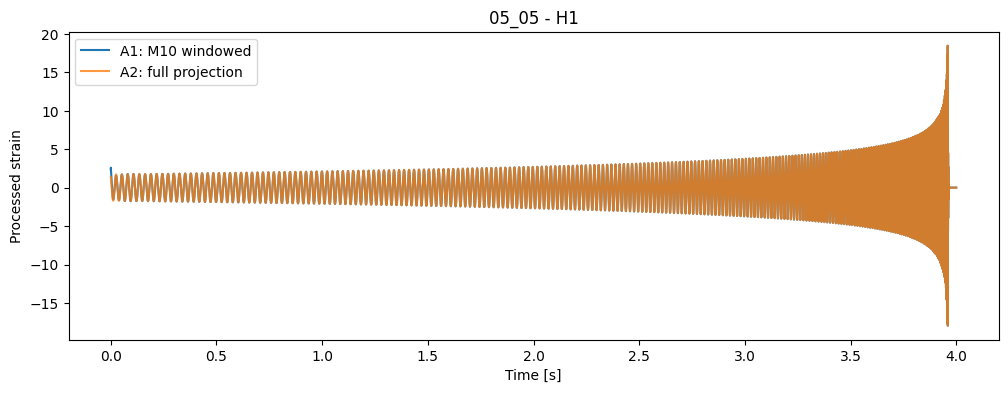

In [10]:
case = "05_05"
ifo = "H1"
idx = ["H1", "L1", "V1"].index(ifo)

x1 = results[case]["A1"].X[idx]
x2 = results[case]["A2"].X[idx]

t = np.arange(len(x1)) / config.sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(t, x1, label="A1: M10 windowed")
plt.plot(t, x2, label="A2: full projection", alpha=0.8)
plt.xlabel("Time [s]")
plt.ylabel("Processed strain")
plt.title(f"{case} - {ifo}")
plt.legend()
plt.show()

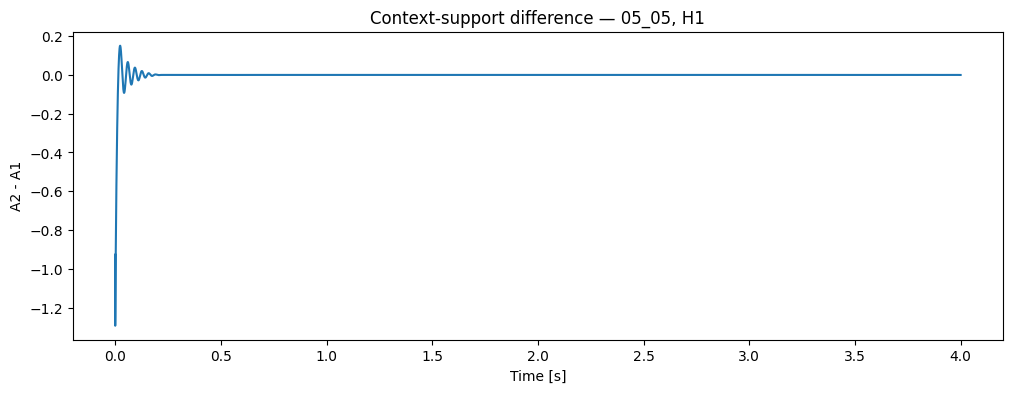

In [11]:
delta = x2 - x1

plt.figure(figsize=(12, 4))
plt.plot(t, delta)
plt.xlabel("Time [s]")
plt.ylabel("A2 - A1")
plt.title(f"Context-support difference — {case}, {ifo}")
plt.show()

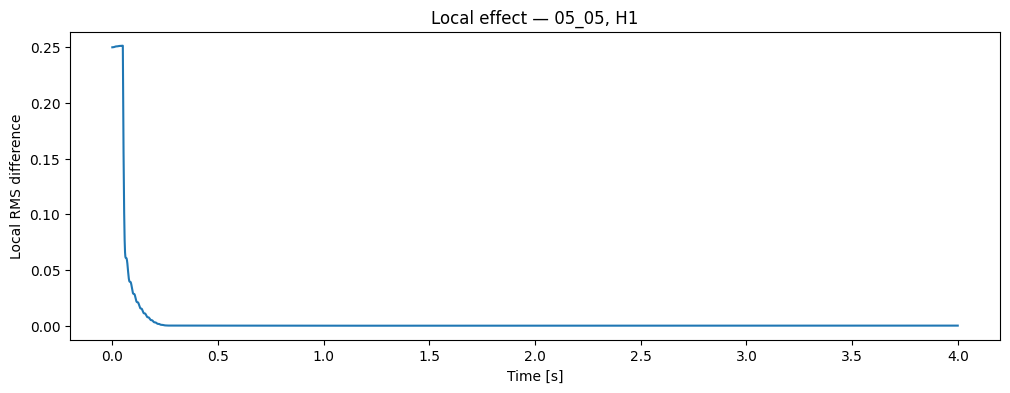

In [12]:
window = int(0.1 * config.sampling_frequency)

local_rms = np.sqrt(
    np.convolve(
        delta**2,
        np.ones(window) / window,
        mode="same",
    )
)

plt.figure(figsize=(12, 4))
plt.plot(t, local_rms)
plt.xlabel("Time [s]")
plt.ylabel("Local RMS difference")
plt.title(f"Local effect — {case}, {ifo}")
plt.show()

### Interpretation of the time-domain plots

The A2−A1 difference is strongly concentrated at the **beginning of the final 4 s output** and decays rapidly toward zero.

This is the qualitative signature expected if the difference is caused by finite temporal support of the whitening operation: adding the missing pre-output inspiral changes the early processed samples, while the rest of the 4 s segment is essentially unaffected.

The local-RMS curve shows that the effect becomes negligible after the first few tenths of a second. This localization is important: the global relative \(L_2\) differences are small because most of the 4 s window is unchanged, not because the boundary effect is absent.


## 9. Waveform durations


In [13]:
for case_name, d in results.items():
    meta = d["A2"].metadata["waveform"]["generated"]

    print(
        case_name,
        "waveform duration:",
        meta["duration"],
        "s"
    )

05_05 waveform duration: 6.51416015625 s
20_20 waveform duration: 0.64208984375 s
40_40 waveform duration: 0.302734375 s
80_80 waveform duration: 0.351806640625 s


### Interpretation

The duration diagnostic explains the complete pattern:

| system | waveform duration | expected A1/A2 difference |
|---|---:|---|
| 5+5 $M_\odot$ | 6.514 s | yes |
| 20+20 $M_\odot$ | 0.642 s | no |
| 40+40 $M_\odot$ | 0.303 s | no |
| 80+80 $M_\odot$ | 0.352 s | no |

The non-monotonic 40+40 vs 80+80 duration is not relevant to this particular experiment; both waveforms are far shorter than the 4 s window. The decisive condition here is simply whether the projected waveform extends beyond the M10 window into the processing context.


## 10. M11.1-A conclusion

The signal-only experiment validates both the implementation and the underlying methodological concern.

1. `full_projection` preserves the final 4 s output geometry while adding physical GW signal to the pre-output processing context.
2. A measurable change appears **only** when the waveform is physically longer than the M10 window.
3. For the 5+5 \(M_\odot\) system, the added support modifies the processed output predominantly near its initial boundary.
4. Higher-mass systems with waveforms shorter than 4 s remain exactly unchanged, providing a strong null control.
5. The effect is modest globally but locally non-negligible. Whether it matters for inference cannot be decided from the signal-only test alone.

**Decision:** the `full_projection` mode is physically better motivated and should remain the candidate M11 behavior. The next step is to test whether the same boundary effect remains relevant once realistic Gaussian noise and M10 input normalization are included.


# 11. Experiment B — Gaussian noise + signal-context comparison

The signal-only experiment A showed that retaining the full physical waveform inside the processing context modifies the processed 4 s output only when the waveform extends beyond the M10 physical window.

The next step is to determine whether this difference remains relevant once the signal is embedded in the same Gaussian-noise domain used by M10.

We define:

$$
B1 = n + h_{\mathrm{M10-windowed}}
$$

$$
B2 = n + h_{\mathrm{full-context}}
$$

where $n(t)$ must be the **same Gaussian-noise realization** in both cases.

The experiment is divided into four levels:

1. verify strict pairing between B1 and B2;
2. compare the processed noisy strain;
3. apply the exact M10 per-sample/per-detector input z-score;
4. propagate both inputs through the frozen M10 CNN and compare embeddings and predictions.

The main physical case remains the \(5+5\,M_\odot\) system, because its waveform extends beyond the 4 s M10 window. A \(20+20\,M_\odot\) system is retained as a null control.

In [14]:
B_CASES = {
    "05_05": cases["05_05"],
    "20_20": cases["20_20"],
}

results_B = {}

for case_name, params in B_CASES.items():

    builder_b1 = make_builder(SEED)
    builder_b2 = make_builder(SEED)

    b1 = builder_b1.build_sample(
        params=params,
        geocentric_coalescence_time=T_GEO,
        placement_policy="random_contained",
        strain_mode="in_noise",
        signal_context_mode="m10_windowed",
    )

    b2 = builder_b2.build_sample(
        params=params,
        geocentric_coalescence_time=T_GEO,
        placement_policy="random_contained",
        strain_mode="in_noise",
        signal_context_mode="full_projection",
    )

    results_B[case_name] = {
        "B1": b1,
        "B2": b2,
    }

## 11.1 Pairing validation

Before interpreting any difference in the noisy outputs, B1 and B2 must be confirmed to represent the same physical event and the same final CNN window.

The only intended difference is the amount of physical GW signal injected inside the processing context.

Therefore we verify:

$$
\theta_{B1} = \theta_{B2},
$$

$$
t_{\mathrm{output},B1} = t_{\mathrm{output},B2},
$$

$$
\rho_{\mathrm{opt},B1} = \rho_{\mathrm{opt},B2},
$$

and identical detector projection metadata.

In [15]:
pairing_rows = []

for case_name, d in results_B.items():

    b1 = d["B1"]
    b2 = d["B2"]

    pc1 = b1.metadata["processing_context"]
    pc2 = b2.metadata["processing_context"]

    snr1 = b1.metadata["snr"]
    snr2 = b2.metadata["snr"]

    proj1 = b1.metadata["projection"]
    proj2 = b2.metadata["projection"]

    pairing_rows.append({
        "case": case_name,
        "same_shape": b1.X.shape == b2.X.shape,
        "same_output_start":
            pc1["output_segment_start_time"]
            == pc2["output_segment_start_time"],
        "same_output_end":
            pc1["output_segment_end_time"]
            == pc2["output_segment_end_time"],
        "same_network_snr":
            np.isclose(
                snr1["final_network_snr"],
                snr2["final_network_snr"],
            ),
        "same_delays":
            proj1["expected_detector_time_delays"]
            == proj2["expected_detector_time_delays"],
        "same_arrival_times":
            proj1["detector_arrival_times"]
            == proj2["detector_arrival_times"],
    })

df_pairing_B = pd.DataFrame(pairing_rows)
df_pairing_B

,case,same_shape,same_output_start,same_output_end,same_network_snr,same_delays,same_arrival_times
0,05_05,True,True,True,True,True,True
1,20_20,True,True,True,True,True,True


## 11.2 Signal injection inside the noisy processing context

The presence of Gaussian noise should not change the signal-support geometry itself.

For the $5+5\,M_\odot$ system, B2 should inject additional physical GW samples into the pre-output context, while the \(20+20\,M_\odot\) null control should remain unchanged.

In [16]:
rows = []

for case_name, d in results_B.items():

    for ifo in ["H1", "L1", "V1"]:

        inj1 = d["B1"].metadata["injection"][ifo]
        inj2 = d["B2"].metadata["injection"][ifo]

        rows.append({
            "case": case_name,
            "ifo": ifo,
            "B1_injected_samples": inj1["n_injected_samples"],
            "B2_injected_samples": inj2["n_injected_samples"],
            "extra_samples":
                inj2["n_injected_samples"]
                - inj1["n_injected_samples"],
            "B2_clipped_before": inj2["n_clipped_before"],
            "B2_clipped_after": inj2["n_clipped_after"],
        })

df_injection_B = pd.DataFrame(rows)
df_injection_B

,case,ifo,B1_injected_samples,B2_injected_samples,extra_samples,B2_clipped_before,B2_clipped_after
0,05_05,H1,16334,17998,1664,8751,0
1,05_05,L1,16315,17979,1664,8770,0
2,05_05,V1,16384,18048,1664,8700,0
3,20_20,H1,2697,2697,0,0,0
4,20_20,L1,2697,2697,0,0,0
5,20_20,V1,2696,2696,0,0,0


## 11.3 Processed noisy-strain comparison

The next comparison is performed on the final processed 4 s outputs before the M10 input z-score.

Because the whitening operation uses the same PSD and is approximately linear, if B1 and B2 contain exactly the same noise realization we expect

$$
B2-B1 \approx A2-A1.
$$

This serves as both a physical and implementation-level consistency check.

However, the relative importance of the perturbation can be much smaller in noisy data because the denominator now contains the full noise contribution.

In [17]:
rows = []

for case_name, d in results_B.items():

    for i, ifo in enumerate(["H1", "L1", "V1"]):

        metrics = comparison_metrics(
            d["B1"].X[i],
            d["B2"].X[i],
        )

        rows.append({
            "case": case_name,
            "ifo": ifo,
            **metrics,
        })

df_metrics_B = pd.DataFrame(rows)
df_metrics_B

,case,ifo,rmse,max_abs_diff,relative_l2,corr
0,05_05,H1,0.039769,1.293667,0.000890,1.0
1,05_05,L1,0.040733,1.450805,0.000912,1.0
2,05_05,V1,0.011411,0.671581,0.000252,1.0
3,20_20,H1,0.000000,0.000000,0.000000,1.0
4,20_20,L1,0.000000,0.000000,0.000000,1.0
5,20_20,V1,0.000000,0.000000,0.000000,1.0


## 11.4 Does the noisy difference reproduce the signal-only difference?

If the two B branches contain the same Gaussian-noise realization, the noise contribution cancels when taking the difference:

$$
\Delta X_B
=
X_{B2}-X_{B1}.
$$

Under a linear processing operator,

$$
\Delta X_B
\approx
X_{A2}-X_{A1}
=
\Delta X_A.
$$

We therefore compare the two difference signals directly.

In [18]:
rows = []

for case_name in B_CASES:

    for i, ifo in enumerate(["H1", "L1", "V1"]):

        delta_A = (
            results[case_name]["A2"].X[i]
            - results[case_name]["A1"].X[i]
        )

        delta_B = (
            results_B[case_name]["B2"].X[i]
            - results_B[case_name]["B1"].X[i]
        )

        abs_diff = delta_B - delta_A

        denom = np.linalg.norm(delta_A)

        rows.append({
            "case": case_name,
            "ifo": ifo,
            "deltaA_l2": np.linalg.norm(delta_A),
            "deltaB_l2": np.linalg.norm(delta_B),
            "deltaB_minus_deltaA_l2":
                np.linalg.norm(abs_diff),
            "relative_delta_mismatch":
                np.linalg.norm(abs_diff) / denom
                if denom > 0 else np.nan,
            "corr_deltaA_deltaB":
                np.corrcoef(delta_A, delta_B)[0, 1]
                if np.std(delta_A) > 0 and np.std(delta_B) > 0
                else np.nan,
        })

df_delta_consistency = pd.DataFrame(rows)
df_delta_consistency

,case,ifo,deltaA_l2,deltaB_l2,deltaB_minus_deltaA_l2,relative_delta_mismatch,corr_deltaA_deltaB
0,05_05,H1,5.090415,5.090415,3.078256e-12,6.047161e-13,1.0
1,05_05,L1,5.213798,5.213798,3.044941e-12,5.840160e-13,1.0
2,05_05,V1,1.460558,1.460558,6.403812e-12,4.384495e-12,1.0
3,20_20,H1,0.000000,0.000000,0.000000e+00,NaN,NaN
4,20_20,L1,0.000000,0.000000,0.000000e+00,NaN,NaN
5,20_20,V1,0.000000,0.000000,0.000000e+00,NaN,NaN


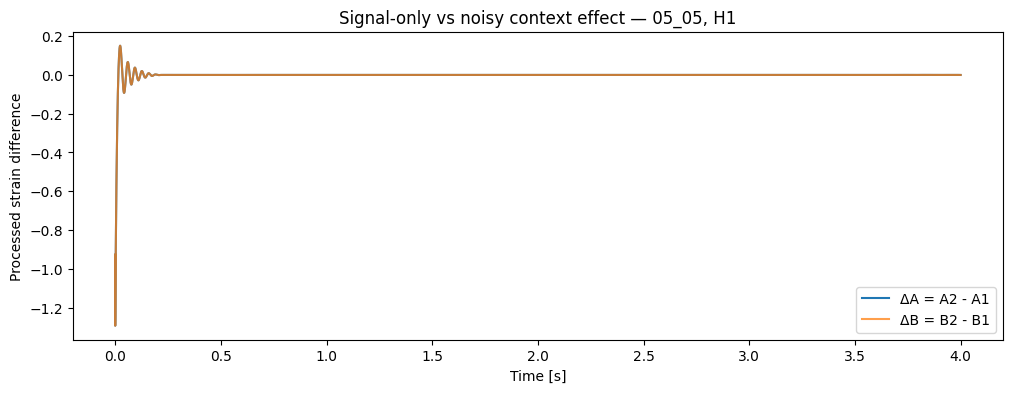

In [19]:
case = "05_05"
ifo = "H1"
idx = ["H1", "L1", "V1"].index(ifo)

delta_A = (
    results[case]["A2"].X[idx]
    - results[case]["A1"].X[idx]
)

delta_B = (
    results_B[case]["B2"].X[idx]
    - results_B[case]["B1"].X[idx]
)

t = np.arange(len(delta_A)) / config.sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(t, delta_A, label="ΔA = A2 - A1")
plt.plot(t, delta_B, label="ΔB = B2 - B1", alpha=0.75)
plt.xlabel("Time [s]")
plt.ylabel("Processed strain difference")
plt.title(f"Signal-only vs noisy context effect — {case}, {ifo}")
plt.legend()
plt.show()

## 11.5 Visual comparison in the noisy domain

Unlike the signal-only experiment, the absolute B1/B2 traces are now dominated by Gaussian noise.

The purpose of this plot is therefore not to identify the context effect visually, but to illustrate its scale relative to the full processed input.

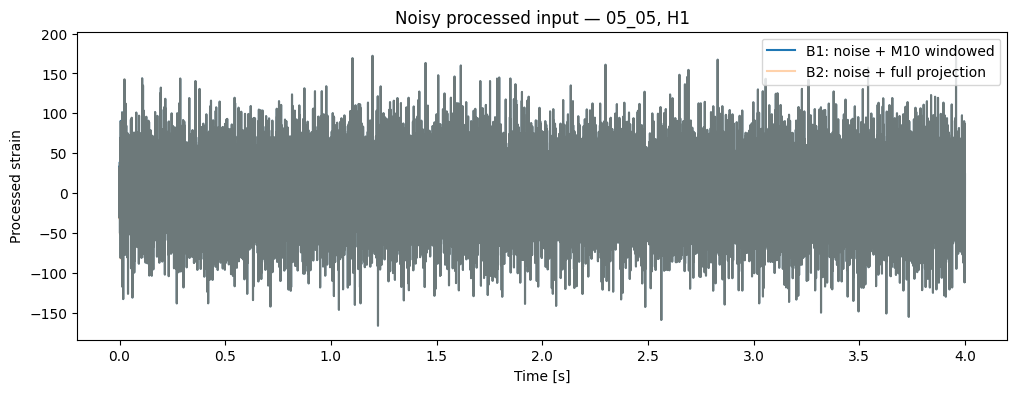

In [20]:
case = "05_05"
ifo = "H1"
idx = ["H1", "L1", "V1"].index(ifo)

x1 = results_B[case]["B1"].X[idx]
x2 = results_B[case]["B2"].X[idx]

t = np.arange(len(x1)) / config.sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(t, x1, label="B1: noise + M10 windowed")
plt.plot(t, x2, label="B2: noise + full projection", alpha=0.35)
plt.xlabel("Time [s]")
plt.ylabel("Processed strain")
plt.title(f"Noisy processed input — {case}, {ifo}")
plt.legend()
plt.show()

# 12. Propagation through the M10 input normalization

M10 applies a z-score independently to each detector channel and each sample:

$$
Z_I(t)
=
\frac{X_I(t)-\mu_I}{\sigma_I}.
$$

This transformation is not linear with respect to the A1/A2 or B1/B2 comparison because the mean and standard deviation are recomputed from each individual channel.

Therefore, even a localized change in the processed strain can alter the normalization factor and propagate globally through the normalized input.

The next step evaluates whether the physically improved signal context remains visible after the exact M10 input normalization.

In [21]:
input_norm_config = {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

In [22]:
def m10_input_zscore(X, input_norm_config):
    """
    Exact M10 per-sample/per-detector input normalization.
    """
    if not input_norm_config["enabled"]:
        return np.asarray(X), None, None

    if input_norm_config["mode"] != "per_sample_per_detector_zscore":
        raise ValueError(
            f"Unsupported normalization mode: "
            f"{input_norm_config['mode']}"
        )

    eps = float(input_norm_config["eps"])

    X = np.asarray(X, dtype=np.float64)

    means = X.mean(axis=1)
    stds = X.std(axis=1)

    if np.any(~np.isfinite(means)):
        raise ValueError("Non-finite input means.")

    if np.any(~np.isfinite(stds)):
        raise ValueError("Non-finite input stds.")

    if np.any(stds < eps):
        raise ValueError(
            f"Input std below eps={eps}: {stds}"
        )

    Xz = (
        X - means[:, None]
    ) / stds[:, None]

    return Xz, means, stds

In [23]:
normalized_B = {}

for case_name, d in results_B.items():

    z1, mean1, std1 = m10_input_zscore(d["B1"].X, input_norm_config)
    z2, mean2, std2 = m10_input_zscore(d["B2"].X, input_norm_config)

    normalized_B[case_name] = {
        "B1": z1,
        "B2": z2,
        "mean_B1": mean1,
        "mean_B2": mean2,
        "std_B1": std1,
        "std_B2": std2,
    }

## 12.1 Effect of the context correction on M10 normalization statistics

Because the z-score is computed separately for every detector and every event, the context correction can affect the channel scale through a change in $\sigma_I$.

We quantify:

$$
\frac{\sigma_{B2,I}-\sigma_{B1,I}}
{\sigma_{B1,I}}.
$$

A very small value would indicate that the context correction remains local after normalization. A larger value would imply that the local boundary change indirectly rescales the full detector channel.

In [24]:
rows = []

for case_name, d in normalized_B.items():

    for i, ifo in enumerate(["H1", "L1", "V1"]):

        std1 = d["std_B1"][i]
        std2 = d["std_B2"][i]

        mean1 = d["mean_B1"][i]
        mean2 = d["mean_B2"][i]

        rows.append({
            "case": case_name,
            "ifo": ifo,
            "mean_B1": mean1,
            "mean_B2": mean2,
            "mean_diff": mean2 - mean1,
            "std_B1": std1,
            "std_B2": std2,
            "std_rel_diff":
                (std2 - std1) / std1,
        })

df_zscore_stats = pd.DataFrame(rows)
df_zscore_stats

,case,ifo,mean_B1,mean_B2,mean_diff,std_B1,std_B2,std_rel_diff
0,05_05,H1,-0.002696,-0.004291,-0.001595,44.665396,44.665352,-9.833321e-07
1,05_05,L1,0.006964,0.008097,0.001132,44.642104,44.642307,4.551653e-06
2,05_05,V1,-0.001547,-0.001405,0.000142,45.224933,45.224851,-1.816054e-06
3,20_20,H1,-0.002121,-0.002121,0.000000,45.797747,45.797747,0.000000e+00
4,20_20,L1,0.003845,0.003845,0.000000,45.537558,45.537558,0.000000e+00
5,20_20,V1,0.012549,0.012549,0.000000,45.142971,45.142971,0.000000e+00


In [25]:
rows = []

for case_name, d in normalized_B.items():

    for i, ifo in enumerate(["H1", "L1", "V1"]):

        metrics = comparison_metrics(
            d["B1"][i],
            d["B2"][i],
        )

        rows.append({
            "case": case_name,
            "ifo": ifo,
            **metrics,
        })

df_metrics_B_zscore = pd.DataFrame(rows)
df_metrics_B_zscore

,case,ifo,rmse,max_abs_diff,relative_l2,corr
0,05_05,H1,0.000890,0.028927,0.000890,1.0
1,05_05,L1,0.000912,0.032472,0.000912,1.0
2,05_05,V1,0.000252,0.014847,0.000252,1.0
3,20_20,H1,0.000000,0.000000,0.000000,1.0
4,20_20,L1,0.000000,0.000000,0.000000,1.0
5,20_20,V1,0.000000,0.000000,0.000000,1.0


## 12.2 Does M10 normalization amplify or suppress the context difference?

We compare the relative $L_2$ difference before and after input normalization.

If the z-score suppresses the difference,

$$
R_z < R_{\mathrm{raw}},
$$

the M10 normalization makes the model less sensitive to this physical correction.

If instead

$$
R_z > R_{\mathrm{raw}},
$$

the normalization amplifies the perturbation in normalized feature space.

In [26]:
raw = (
    df_metrics_B[
        ["case", "ifo", "relative_l2"]
    ]
    .rename(
        columns={"relative_l2": "relative_l2_raw"}
    )
)

zsc = (
    df_metrics_B_zscore[
        ["case", "ifo", "relative_l2"]
    ]
    .rename(
        columns={"relative_l2": "relative_l2_zscore"}
    )
)

df_raw_vs_zscore = raw.merge(
    zsc,
    on=["case", "ifo"],
)

df_raw_vs_zscore["zscore_to_raw_ratio"] = (
    df_raw_vs_zscore["relative_l2_zscore"]
    / df_raw_vs_zscore["relative_l2_raw"]
)

df_raw_vs_zscore

,case,ifo,relative_l2_raw,relative_l2_zscore,zscore_to_raw_ratio
0,05_05,H1,0.000890,0.000890,0.999195
1,05_05,L1,0.000912,0.000912,0.999599
2,05_05,V1,0.000252,0.000252,0.999898
3,20_20,H1,0.000000,0.000000,NaN
4,20_20,L1,0.000000,0.000000,NaN
5,20_20,V1,0.000000,0.000000,NaN


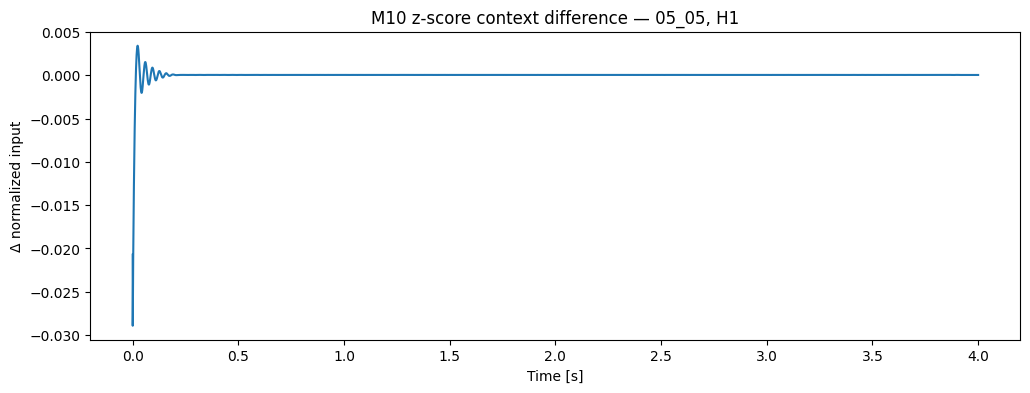

In [27]:
case = "05_05"
ifo = "H1"
idx = ["H1", "L1", "V1"].index(ifo)

z1 = normalized_B[case]["B1"][idx]
z2 = normalized_B[case]["B2"][idx]

delta_z = z2 - z1

t = np.arange(len(z1)) / config.sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(t, delta_z)
plt.xlabel("Time [s]")
plt.ylabel("Δ normalized input")
plt.title(f"M10 z-score context difference — {case}, {ifo}")
plt.show()

# 13. Propagation through the frozen M10 CNN

The final step of M11.1 evaluates whether the physical-context correction is visible to the frozen M10 predictor.

No model is retrained.

The frozen M10 prediction artifact is used as the baseline manifest because it stores:

- the train-only label statistics;
- the exact model configuration;
- the input-normalization configuration;
- the reference checkpoint used for M10 evaluation.

The corresponding PyTorch checkpoint provides the trained `model_state_dict`.

We reconstruct the architecture from the stored configuration rather than defining it manually, ensuring exact consistency with M10.

## 13.0 Load the frozen M10 checkpoint

The M10 prediction artifact stores the exact checkpoint path, label statistics and model configuration used to generate the reference calibration/test predictions.

To avoid reconstructing the architecture manually, we recover this information directly from the saved M10 artifact and then:

1. load the PyTorch checkpoint;
2. recover the stored model configuration;
3. instantiate the corresponding network class;
4. load the trained `model_state_dict`;
5. switch the network to evaluation mode.

No M11 model is trained or modified in this step.

In [28]:
from pathlib import Path
import importlib
import torch

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

PRED_PATH = (
    DATA_ROOT
    / "results"
    / DATASET_ID
    / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz"
)

CHECKPOINT_PATH = (
    DATA_ROOT
    / "models"
    / "checkpoints"
    / DATASET_ID
    / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
        "SimpleCNN_ResidualDilated_"
        "M10_inputzscore_resdilated_emb64_d124_train400k_"
        "MSELoss_seed123_checkpoint.pt"
    )
)

assert PRED_PATH.exists(), PRED_PATH
assert CHECKPOINT_PATH.exists(), CHECKPOINT_PATH

print("Prediction artifact:", PRED_PATH)
print("Checkpoint:", CHECKPOINT_PATH)

Prediction artifact: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz
Checkpoint: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt


## 13.1 Recover the exact M10 model contract

The prediction artifact and checkpoint are independently checked for consistency.

The checkpoint is treated as the source of the trained weights, while the saved M10 prediction artifact provides an independent record of the model configuration, label statistics and input normalization used during the frozen M10 evaluation.

In [29]:
pred_data = np.load(
    PRED_PATH,
    allow_pickle=True,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

# Frozen M10 metadata
label_mean = pred_data["y_mean"].astype(np.float32)
label_std = pred_data["y_std"].astype(np.float32)
label_names = [
    str(x)
    for x in pred_data["label_names"].tolist()
]

model_config_pred = pred_data["model_config"].item()
input_norm_config = pred_data["input_normalization"].item()

model_config_ckpt = checkpoint["model_config"]

print("Device:", device)
print("Labels:", label_names)
print("Input normalization:", input_norm_config)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])

Device: cpu
Labels: ['chirp_mass', 'total_mass', 'chi_eff']
Input normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}
Checkpoint epoch: 69
Best validation loss: 0.11357601894140243


In [30]:
assert model_config_ckpt == model_config_pred

assert np.allclose(
    checkpoint["y_mean"],
    label_mean,
)

assert np.allclose(
    checkpoint["y_std"],
    label_std,
)

assert (
    model_config_ckpt["input_normalization"]
    == input_norm_config
)

assert input_norm_config == {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

print("M10 model contract verified.")

M10 model contract verified.


In [31]:
model_config = model_config_ckpt

network_module = importlib.import_module(
    "src.models.network"
)

class_name = model_config["class_name"]
model_kwargs = dict(
    model_config["model_kwargs"]
)

model_class = getattr(
    network_module,
    class_name,
)

model = model_class(
    **model_kwargs,
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    f"Loaded frozen M10 model: {class_name}"
)
print("Model kwargs:")
model_kwargs

Loaded frozen M10 model: SimpleCNN_ResidualDilated
Model kwargs:


{'n_detectors': 3,
 'n_outputs': 3,
 'embedding_dim': 64,
 'residual_channels': 64,
 'dilations': [1, 2, 4],
 'residual_kernel_size': 7,
 'dropout_conv': 0.05,
 'dropout_dense': 0.1,
 'num_groups': 8}

## 13.2 Build paired normalized CNN inputs

B1 and B2 have already been processed with the same physical and numerical pipeline and independently normalized with the exact M10 per-sample/per-detector z-score.

They are now converted to PyTorch tensors without any further preprocessing.

In [32]:
network_inputs = {}

for case_name, d in normalized_B.items():

    network_inputs[case_name] = {
        mode: torch.as_tensor(
            d[mode],
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)
        for mode in ["B1", "B2"]
    }

for case_name, d in network_inputs.items():
    print(
        case_name,
        d["B1"].shape,
        d["B2"].shape,
    )

05_05 torch.Size([1, 3, 16384]) torch.Size([1, 3, 16384])
20_20 torch.Size([1, 3, 16384]) torch.Size([1, 3, 16384])


## 13.3 Frozen-M10 inference

For each paired input, the network returns both:

- the standardized parameter prediction;
- the 64-dimensional latent embedding.

Because the model is in evaluation mode and gradients are disabled, the comparison contains no training-time stochasticity.

In [33]:
network_outputs = {}

model.eval()

with torch.no_grad():

    for case_name, d in network_inputs.items():

        pred_b1, emb_b1 = model(
            d["B1"],
            return_embedding=True,
        )

        pred_b2, emb_b2 = model(
            d["B2"],
            return_embedding=True,
        )

        network_outputs[case_name] = {
            "pred_B1_std": pred_b1.cpu().numpy()[0],
            "pred_B2_std": pred_b2.cpu().numpy()[0],
            "emb_B1": emb_b1.cpu().numpy()[0],
            "emb_B2": emb_b2.cpu().numpy()[0],
        }

In [34]:
if "model_config" not in checkpoint:
    raise KeyError(
        "Checkpoint does not contain 'model_config'."
    )

model_config = checkpoint["model_config"]

print("Model config from checkpoint:")
print(model_config)



Model config from checkpoint:
{'architecture': 'SimpleCNN_ResidualDilated', 'class_name': 'SimpleCNN_ResidualDilated', 'dataset_id': 'bbh_processed_4s_seobnrv4opt_snr10-25_n500_000', 'dataset_format': 'hdf5', 'dataset_path': '/data/vserrano/cbc_pe/data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000.h5', 'split_path': '/data/vserrano/cbc_pe/data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_splits_train400000_val40000_cal30000_test30000_seed123.npz', 'label_stats_path': '/data/vserrano/cbc_pe/data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz', 'n_samples': 500000, 'n_detectors': 3, 'signal_length': 16384, 'n_outputs': 3, 'label_names': ['chirp_mass', 'total_mass', 'chi_eff'], 'model_kwargs': {'n_detectors': 3, 'n_outputs': 3, 'embedding_dim': 64, 'residual_channels': 64, 'dilations': [1, 2, 4], 'residual_kernel_size': 7, 'dropout_conv': 0.05, 'dropout_dense': 0.1, 'num_groups': 8}

### Checkpoint consistency check

Before applying the network to the new M11.1 samples, verify that the loaded model corresponds to the same checkpoint and label transformation used to generate the frozen M10 prediction artifact.

## 13.4 Latent-space displacement

The input perturbation may be small in waveform space but still produce a measurable displacement in the learned 64-dimensional representation.

We therefore compute the absolute and relative embedding displacement:

$$
d_z
=
\|\mathbf z_{B2}-\mathbf z_{B1}\|_2
$$

and

$$
r_z
=
\frac{
\|\mathbf z_{B2}-\mathbf z_{B1}\|_2
}{
\|\mathbf z_{B1}\|_2
}.
$$

In [35]:
rows = []

for case_name, d in network_outputs.items():

    emb1 = d["emb_B1"]
    emb2 = d["emb_B2"]

    delta = emb2 - emb1

    rows.append({
        "case": case_name,
        "embedding_l2_B1":
            np.linalg.norm(emb1),
        "embedding_delta_l2":
            np.linalg.norm(delta),
        "embedding_relative_delta":
            np.linalg.norm(delta)
            / np.linalg.norm(emb1),
        "embedding_cosine":
            np.dot(emb1, emb2)
            / (
                np.linalg.norm(emb1)
                * np.linalg.norm(emb2)
            ),
    })

df_embedding_shift = pd.DataFrame(rows)
df_embedding_shift

,case,embedding_l2_B1,embedding_delta_l2,embedding_relative_delta,embedding_cosine
0,05_05,3.199581,0.025592,0.007999,0.999978
1,20_20,2.356648,0.000000,0.000000,1.000000


### Interpretation

For the $5+5\,M_\odot$ system, including the physically correct pre-output signal context produces a non-zero displacement in the M10 latent representation,

$$
\frac{\|\Delta z\|_2}{\|z_{B1}\|_2}
\simeq 8\times10^{-3},
$$

while the cosine similarity remains extremely close to unity.

Therefore, the context correction is detectable by the CNN representation, but it does not move the event to a substantially different region of latent space.

For the $20+20\,M_\odot$ null control, the embeddings are exactly identical, consistent with the fact that its physical waveform is already shorter than the 4 s M10 window.

In [36]:
def inverse_standardize_labels(y_std, mean, std):
    return y_std * std + mean

In [37]:
LABELS = [
    "chirp_mass",
    "total_mass",
    "chi_eff",
]

rows = []

for case_name, d in network_outputs.items():

    pred_b1 = (
        d["pred_B1_std"] * label_std
        + label_mean
    )

    pred_b2 = (
        d["pred_B2_std"] * label_std
        + label_mean
    )

    params = B_CASES[case_name]

    true_values = {
        "chirp_mass": params.chirp_mass,
        "total_mass": params.total_mass,
        "chi_eff": params.chi_eff,
    }

    for j, label in enumerate(LABELS):

        true = true_values[label]

        err_b1 = pred_b1[j] - true
        err_b2 = pred_b2[j] - true

        rows.append({
            "case": case_name,
            "label": label,
            "true": true,
            "pred_B1": pred_b1[j],
            "pred_B2": pred_b2[j],
            "delta_B2_minus_B1":
                pred_b2[j] - pred_b1[j],
            "error_B1":
                err_b1,
            "error_B2":
                err_b2,
            "abs_error_B1":
                abs(err_b1),
            "abs_error_B2":
                abs(err_b2),
            "delta_abs_error":
                abs(err_b2) - abs(err_b1),
        })

df_prediction_shift = pd.DataFrame(rows)

df_prediction_shift

,case,label,true,pred_B1,pred_B2,delta_B2_minus_B1,error_B1,error_B2,abs_error_B1,abs_error_B2,delta_abs_error
0,05_05,chirp_mass,4.352753,9.317699,9.383562,0.065863,4.964947,5.030809,4.964947,5.030809,0.065863
1,05_05,total_mass,10.000000,24.788910,25.006142,0.217232,14.788910,15.006142,14.788910,15.006142,0.217232
2,05_05,chi_eff,0.000000,0.175204,0.180848,0.005644,0.175204,0.180848,0.175204,0.180848,0.005644
3,20_20,chirp_mass,17.411011,17.101343,17.101343,0.000000,-0.309668,-0.309668,0.309668,0.309668,0.000000
4,20_20,total_mass,40.000000,46.351570,46.351570,0.000000,6.351570,6.351570,6.351570,6.351570,0.000000
5,20_20,chi_eff,0.000000,-0.054445,-0.054445,0.000000,-0.054445,-0.054445,0.054445,0.054445,0.000000


In [38]:
truth = {}

for case_name, params in B_CASES.items():
    truth[case_name] = {
        "chirp_mass": params.chirp_mass,
        "total_mass": params.total_mass,
        "chi_eff": params.chi_eff,
    }

df_prediction_shift["true_value"] = [
    truth[row["case"]][row["label"]]
    for _, row in df_prediction_shift.iterrows()
]

df_prediction_shift["B1_residual"] = (
    df_prediction_shift["true_value"]
    - df_prediction_shift["pred_B1"]
)

df_prediction_shift["B2_residual"] = (
    df_prediction_shift["true_value"]
    - df_prediction_shift["pred_B2"]
)

df_prediction_shift["abs_error_change"] = (
    np.abs(df_prediction_shift["B2_residual"])
    - np.abs(df_prediction_shift["B1_residual"])
)

df_prediction_shift

,case,label,true,pred_B1,pred_B2,delta_B2_minus_B1,error_B1,error_B2,abs_error_B1,abs_error_B2,delta_abs_error,true_value,B1_residual,B2_residual,abs_error_change
0,05_05,chirp_mass,4.352753,9.317699,9.383562,0.065863,4.964947,5.030809,4.964947,5.030809,0.065863,4.352753,-4.964947,-5.030809,0.065863
1,05_05,total_mass,10.000000,24.788910,25.006142,0.217232,14.788910,15.006142,14.788910,15.006142,0.217232,10.000000,-14.788910,-15.006142,0.217232
2,05_05,chi_eff,0.000000,0.175204,0.180848,0.005644,0.175204,0.180848,0.175204,0.180848,0.005644,0.000000,-0.175204,-0.180848,0.005644
3,20_20,chirp_mass,17.411011,17.101343,17.101343,0.000000,-0.309668,-0.309668,0.309668,0.309668,0.000000,17.411011,0.309668,0.309668,0.000000
4,20_20,total_mass,40.000000,46.351570,46.351570,0.000000,6.351570,6.351570,6.351570,6.351570,0.000000,40.000000,-6.351570,-6.351570,0.000000
5,20_20,chi_eff,0.000000,-0.054445,-0.054445,0.000000,-0.054445,-0.054445,0.054445,0.054445,0.000000,0.000000,0.054445,0.054445,0.000000


### Prediction-level interpretation

The context correction has only a small effect on the frozen M10 point estimates.

For the $5+5\,M_\odot$ case, B2 changes the predictions by approximately:

$$
\Delta\mathcal M \simeq 0.066\,M_\odot,
$$

$$
\Delta M_{\rm tot} \simeq 0.217\,M_\odot,
$$

$$
\Delta\chi_{\rm eff} \simeq 5.6\times10^{-3}.
$$

These shifts are much smaller than the pre-existing prediction errors of B1.

Therefore, the poor prediction obtained for the $5+5\,M_\odot$ system is **not caused by the M10 physical-context truncation**.

The $20+20\,M_\odot$ null control remains exactly unchanged between B1 and B2.

> **Important limitation of this diagnostic**
>
> The $5+5\,M_\odot$ system lies at the extreme lower boundary of the component-mass prior used to train M10. In addition, SNR targeting was deliberately disabled in the present M11.1 experiment in order to isolate the signal-context effect.
>
> Therefore, the absolute prediction error observed here must not yet be interpreted as a calibrated measurement of M10 performance at low masses.
>
> The result only supports the narrower conclusion required by M11.1:
>
> **the physical-context correction produces a small change in the M10 representation and prediction, while the dominant low-mass prediction error already exists independently of that correction.**

# 14. M11.1-B interpretation

The B experiment answers three increasingly relevant questions:

### 1. Does the physical-context correction survive Gaussian noise?

This is assessed through the raw processed B1/B2 difference and the consistency between

$$
\Delta X_B
$$

and

$$
\Delta X_A.
$$

### 2. Does the M10 per-detector z-score suppress or amplify the difference?

This is assessed through the relative input displacement before and after normalization, together with changes in the per-detector normalization statistics.

### 3. Is the difference visible to the frozen M10 CNN?

This is assessed through the latent-space displacement and the change in physical point predictions.

A single $5+5\,M_\odot$ realization is only a diagnostic case. If the CNN shows a measurable response, the next step will be to repeat the paired experiment over a controlled low-mass sample to estimate the distribution of embedding and prediction shifts.